In [3]:
from scipy.io import loadmat

data = loadmat("../datasets/duke/2015_BOE_Chiu/Subject_01.mat")

print(data.keys())
for key in data.keys():
    if key.startswith("__"):
        continue

    print("=" * 50)
    print(key)
    print(type(data[key]))
    print(data[key].shape)

images = data["images"]

print(images.shape)
print(images.dtype)
print(images.min())
print(images.max())

dict_keys(['__header__', '__version__', '__globals__', 'images', 'automaticFluidDME', 'manualFluid1', 'manualFluid2', 'automaticLayersDME', 'automaticLayersNormal', 'manualLayers1', 'manualLayers2'])
images
<class 'numpy.ndarray'>
(496, 768, 61)
automaticFluidDME
<class 'numpy.ndarray'>
(496, 768, 61)
manualFluid1
<class 'numpy.ndarray'>
(496, 768, 61)
manualFluid2
<class 'numpy.ndarray'>
(496, 768, 61)
automaticLayersDME
<class 'numpy.ndarray'>
(8, 768, 61)
automaticLayersNormal
<class 'numpy.ndarray'>
(8, 768, 61)
manualLayers1
<class 'numpy.ndarray'>
(8, 768, 61)
manualLayers2
<class 'numpy.ndarray'>
(8, 768, 61)
(496, 768, 61)
uint8
0
255


(np.float64(-0.5), np.float64(767.5), np.float64(495.5), np.float64(-0.5))

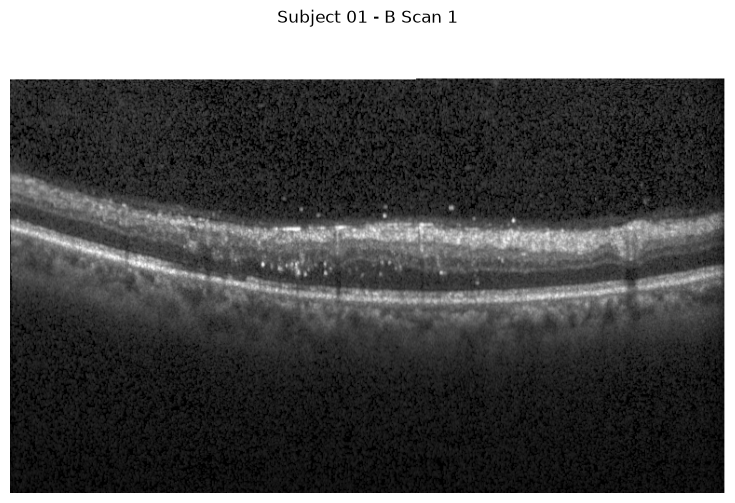

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(images[:,:,9], cmap="gray")

plt.title("Subject 01 - B Scan 1")

plt.axis("off")

In [5]:
layers = data["manualLayers1"]

print(layers.shape)

boundary = layers[0,:,0]

print(boundary.shape)

print(boundary[:20])

(8, 768, 61)
(768,)
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]


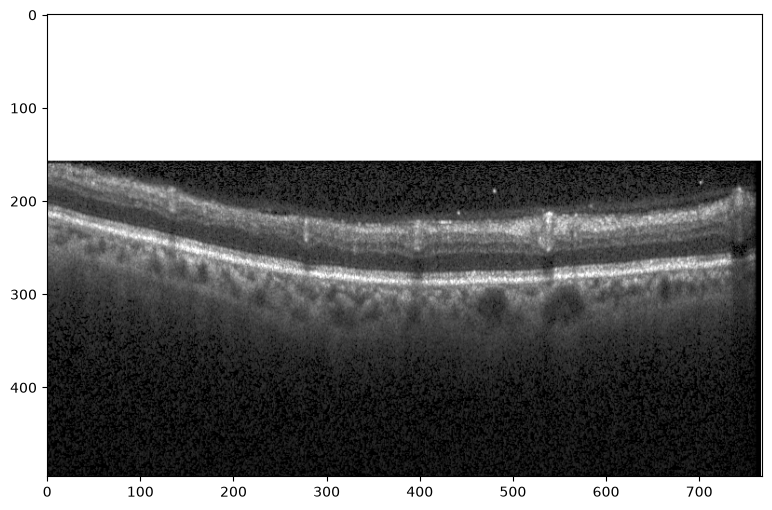

In [6]:
import numpy as np

img = images[:,:,0]

boundary = layers[0,:,0]

plt.figure(figsize=(12,6))

plt.imshow(img,cmap="gray")

plt.plot(np.arange(768), boundary, color="red")

plt.show()

In [7]:
import numpy as np

boundary = layers[0, :, 10]

print("NaNs:", np.isnan(boundary).sum())
print("Valid points:", np.sum(~np.isnan(boundary)))
valid = boundary[~np.isnan(boundary)]

print(valid.min())
print(valid.max())
print(valid[:20])

NaNs: 232
Valid points: 536
185.0
218.0
[185. 185. 186. 186. 186. 186. 187. 187. 187. 187. 188. 188. 188. 189.
 189. 189. 189. 190. 190. 190.]


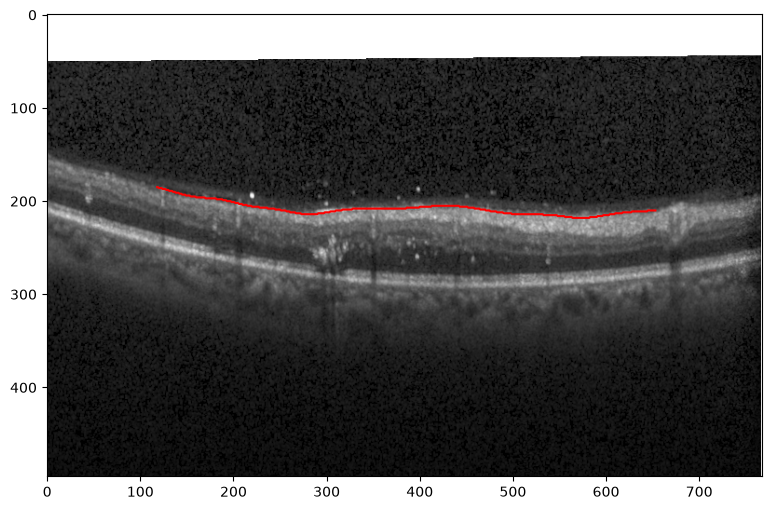

In [8]:
import numpy as np

img = images[:,:,10]

boundary = layers[0,:,10]

plt.figure(figsize=(12,6))

plt.imshow(img,cmap="gray")

plt.plot(np.arange(768), boundary, color="red")

plt.show()

In [9]:
import numpy as np

layers = data["manualLayers2"]

for scan in range(61):
    boundary = layers[0,:,scan]
    valid = np.sum(~np.isnan(boundary))
    print(f"Scan {scan}: {valid}/768 valid points")

Scan 0: 0/768 valid points
Scan 1: 0/768 valid points
Scan 2: 0/768 valid points
Scan 3: 0/768 valid points
Scan 4: 0/768 valid points
Scan 5: 0/768 valid points
Scan 6: 0/768 valid points
Scan 7: 0/768 valid points
Scan 8: 0/768 valid points
Scan 9: 0/768 valid points
Scan 10: 536/768 valid points
Scan 11: 0/768 valid points
Scan 12: 0/768 valid points
Scan 13: 0/768 valid points
Scan 14: 0/768 valid points
Scan 15: 536/768 valid points
Scan 16: 0/768 valid points
Scan 17: 0/768 valid points
Scan 18: 0/768 valid points
Scan 19: 0/768 valid points
Scan 20: 536/768 valid points
Scan 21: 0/768 valid points
Scan 22: 0/768 valid points
Scan 23: 0/768 valid points
Scan 24: 0/768 valid points
Scan 25: 536/768 valid points
Scan 26: 0/768 valid points
Scan 27: 0/768 valid points
Scan 28: 536/768 valid points
Scan 29: 0/768 valid points
Scan 30: 536/768 valid points
Scan 31: 0/768 valid points
Scan 32: 536/768 valid points
Scan 33: 0/768 valid points
Scan 34: 0/768 valid points
Scan 35: 536/768

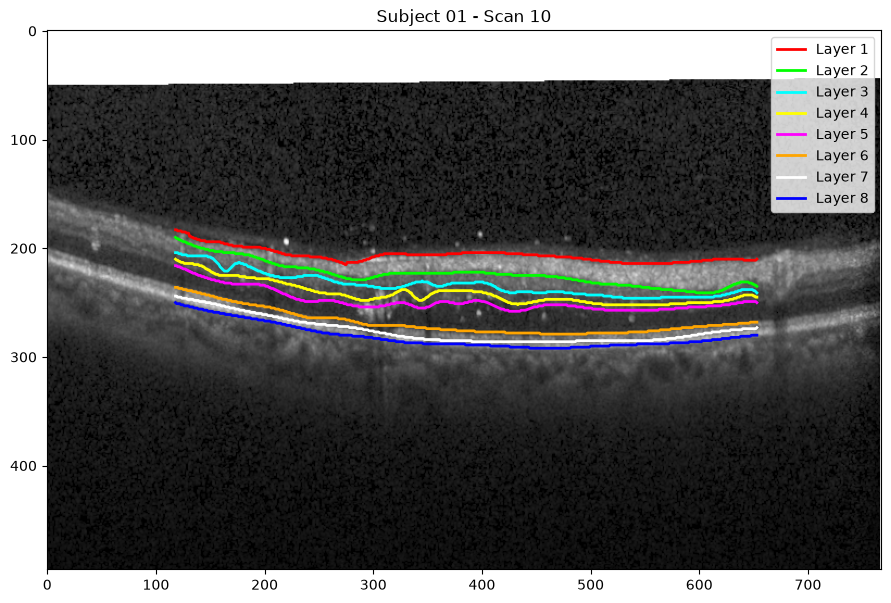

Layer 1: 206.0
Layer 2: 223.0
Layer 3: 231.0
Layer 4: 245.0
Layer 5: 254.0
Layer 6: 274.0
Layer 7: 284.0
Layer 8: 288.0


In [10]:
import matplotlib.pyplot as plt
import numpy as np

scan = 10

img = images[:, :, scan]

plt.figure(figsize=(14, 7))
plt.imshow(img, cmap="gray")

colors = [
    "red",
    "lime",
    "cyan",
    "yellow",
    "magenta",
    "orange",
    "white",
    "blue",
]

for layer in range(8):
    boundary = layers[layer, :, scan]

    valid = ~np.isnan(boundary)

    plt.plot(
        np.arange(768)[valid],
        boundary[valid],
        color=colors[layer],
        linewidth=2,
        label=f"Layer {layer+1}"
    )

plt.legend()
plt.title(f"Subject 01 - Scan {scan}")
plt.show()

scan = 10
x = 350

for layer in range(8):
    print(
        f"Layer {layer+1}:",
        layers[layer, x, scan]
    )

## Inspect all retinal layers together
This cell overlays the detected layer boundaries for a single scan, making it easier to compare the anatomy across multiple layers at once.

In [12]:
scan = 10

image = images[:, :, scan]

mask = np.zeros_like(image, dtype=np.uint8)

print(mask.shape)

(496, 768)


## Prepare a blank mask container
This final setup creates an empty array that will later hold the segmentation mask for the selected scan.